# Postulats de la Mesure Quantique — Règle de Born et Réduction

**Référence :** Cohen-Tannoudji, Diu, Laloë — *Mécanique Quantique Tome I*, Ch. III §B-3-b et §B-3-c

---

## Postulat III — Règle de Born (Règle R2.2)

Si l'on mesure l'observable $A$ sur un système dans l'état $|\psi\rangle$, la probabilité d'obtenir la valeur propre $a_n$ est :
$$P(a_n) = |\langle u_n|\psi\rangle|^2$$
où $|u_n\rangle$ est le vecteur propre associé à $a_n$ et $A|u_n\rangle = a_n|u_n\rangle$.

## Postulat IV — Réduction du paquet d'ondes (Règle R2.3)

Après une mesure ayant donné $a_n$, l'état devient :
$$|\psi'\rangle = \frac{\hat{P}_n|\psi\rangle}{\sqrt{\langle\psi|\hat{P}_n|\psi\rangle}}$$
où $\hat{P}_n = |u_n\rangle\langle u_n|$ est le projecteur sur le sous-espace propre.

**Conséquence :** Deux mesures successives de $A$ donnent **toujours le même résultat**.

## Système — Puits infini 1D

$$\psi_n(x) = \sqrt{\frac{2}{L}}\sin\!\left(\frac{n\pi x}{L}\right), \quad E_n = \frac{n^2\pi^2\hbar^2}{2mL^2}$$

État de superposition :
$$|\psi\rangle = c_1|\psi_1\rangle + c_2|\psi_2\rangle + c_3|\psi_3\rangle \quad \text{avec} \quad \sum_n|c_n|^2 = 1$$

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parents[2]))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

from quantum_simulation.utils.config_loader import load_config
from quantum_simulation.systems.potential_systems import InfiniteWell
from quantum_simulation.core.state import WaveFunctionState

config = load_config()
hbar = config['physical_constants']['hbar']
m    = config['physical_constants']['m_electron']

print(f"ℏ = {hbar:.6e} J·s")
print(f"m = {m:.6e} kg")

✓ Numba CUDA disponible
  Compute Capability : 8.9
ℏ = 1.054572e-34 J·s
m = 9.109384e-31 kg


## 1. Construction de l'état de superposition

In [2]:
# Paramètres puits infini
L  = 1e-9  # largeur (m)
nx = 2048
x  = np.linspace(0, L, nx)

well = InfiniteWell(width=L, mass=m, hbar=hbar)

# États propres (niveaux 1, 2, 3)
psi1 = well.eigenstate_wavefunction(1, x)
psi2 = well.eigenstate_wavefunction(2, x)
psi3 = well.eigenstate_wavefunction(3, x)

E1 = well.energy_eigenvalue(1)
E2 = well.energy_eigenvalue(2)
E3 = well.energy_eigenvalue(3)

print("Niveaux d'énergie du puits infini :")
print(f"  E₁ = {E1:.4e} J  ({E1/1.602e-19:.4f} eV)")
print(f"  E₂ = {E2:.4e} J  ({E2/1.602e-19:.4f} eV)  = 4E₁")
print(f"  E₃ = {E3:.4e} J  ({E3/1.602e-19:.4f} eV)  = 9E₁")

# Coefficients superposition (normalisés)
c1 = 1/np.sqrt(2)   # P(E₁) = 1/2
c2 = 1/2            # P(E₂) = 1/4
c3 = 1/2            # P(E₃) = 1/4

# Vérification : |c₁|² + |c₂|² + |c₃|² = 1
print(f"\nCoefficients : c₁={c1:.4f}, c₂={c2:.4f}, c₃={c3:.4f}")
print(f"  |c₁|²+|c₂|²+|c₃|² = {abs(c1)**2+abs(c2)**2+abs(c3)**2:.6f} (doit être 1)")

# Superposition
psi_super = WaveFunctionState(
    x,
    c1*psi1.wavefunction + c2*psi2.wavefunction + c3*psi3.wavefunction
)
# Renormalisation (somme numérique ≈ 1, sécurité)
psi_super = psi_super.normalize()
print(f"\n  ||ψ_super|| = {psi_super.norm():.12f}")

Niveaux d'énergie du puits infini :
  E₁ = 6.0247e-20 J  (0.3761 eV)
  E₂ = 2.4099e-19 J  (1.5043 eV)  = 4E₁
  E₃ = 5.4222e-19 J  (3.3846 eV)  = 9E₁

Coefficients : c₁=0.7071, c₂=0.5000, c₃=0.5000
  |c₁|²+|c₂|²+|c₃|² = 1.000000 (doit être 1)

  ||ψ_super|| = 1.000000000000


## 2. Calcul des probabilités — Règle de Born (R2.2)

$$P(E_n) = |c_n|^2 = |\langle\psi_n|\psi\rangle|^2$$

In [3]:
# Calcul produits scalaires ⟨ψₙ|ψ_super⟩
dx = x[1] - x[0]

def inner_product(psi_a, psi_b, dx):
    """⟨a|b⟩ = ∫ ψ_a*(x) ψ_b(x) dx  (règle R1.1)"""
    return np.trapz(np.conj(psi_a) * psi_b, dx=dx)

overlap_1 = inner_product(psi1.wavefunction, psi_super.wavefunction, dx)
overlap_2 = inner_product(psi2.wavefunction, psi_super.wavefunction, dx)
overlap_3 = inner_product(psi3.wavefunction, psi_super.wavefunction, dx)

# Probabilités numériques P(Eₙ) = |⟨ψₙ|ψ⟩|²
P1_numeric = abs(overlap_1)**2
P2_numeric = abs(overlap_2)**2
P3_numeric = abs(overlap_3)**2

# Probabilités analytiques
P1_th = abs(c1)**2
P2_th = abs(c2)**2
P3_th = abs(c3)**2

print("Règle de Born P(Eₙ) = |⟨ψₙ|ψ⟩|²")
print("-" * 55)
print(f"{'n':>3} | {'P(Eₙ) analytique':>18} | {'P(Eₙ) numérique':>17} | {'Écart':>10}")
print("-" * 55)
for n, (Pth, Pnum) in enumerate(zip([P1_th,P2_th,P3_th],[P1_numeric,P2_numeric,P3_numeric]), start=1):
    print(f"  {n} | {Pth:18.6f} | {Pnum:17.6f} | {abs(Pth-Pnum):10.2e}")
print("-" * 55)
print(f"  Σ P(Eₙ) numérique = {P1_numeric+P2_numeric+P3_numeric:.8f}  (doit être 1)")

energie_vals = [E1, E2, E3]
proba_th     = [P1_th, P2_th, P3_th]

Règle de Born P(Eₙ) = |⟨ψₙ|ψ⟩|²
-------------------------------------------------------
  n |   P(Eₙ) analytique |   P(Eₙ) numérique |      Écart
-------------------------------------------------------
  1 |           0.500000 |          0.500000 |   0.00e+00
  2 |           0.250000 |          0.250000 |   0.00e+00
  3 |           0.250000 |          0.250000 |   0.00e+00
-------------------------------------------------------
  Σ P(Eₙ) numérique = 1.00000000  (doit être 1)


## 3. Simulation de N = 2000 mesures indépendantes

Chaque mesure est un **tirage aléatoire** selon la distribution de Born (Décision D5 : `np.random.choice`).

In [4]:
N_mesures = 2000
np.random.seed(42)  # reproductibilité

# Tirage : chaque mesure donne Eₙ avec P(Eₙ)
resultats = np.random.choice(
    a=energie_vals,
    size=N_mesures,
    p=proba_th  # distribution Born
)

# Fréquences empiriques
counts   = np.array([np.sum(resultats == E) for E in energie_vals])
freqs    = counts / N_mesures

print(f"Simulation de {N_mesures} mesures indépendantes :")
print("-" * 60)
print(f"{'n':>3} | {'Eₙ (eV)':>12} | {'Fréquence':>10} | {'P(Eₙ) th.':>10} | {'Écart':>8}")
print("-" * 60)
for n, (E, f, p) in enumerate(zip(energie_vals, freqs, proba_th), start=1):
    print(f"  {n} | {E/1.602e-19:12.4f} | {f:10.4f}   | {p:10.4f}   | {abs(f-p):8.4f}")
print("-" * 60)

Simulation de 2000 mesures indépendantes :
------------------------------------------------------------
  n |      Eₙ (eV) |  Fréquence |  P(Eₙ) th. |    Écart
------------------------------------------------------------
  1 |       0.3761 |     0.4935   |     0.5000   |   0.0065
  2 |       1.5043 |     0.2560   |     0.2500   |   0.0060
  3 |       3.3846 |     0.2505   |     0.2500   |   0.0005
------------------------------------------------------------


## 4. Test statistique — χ² de Pearson

Valider que la distribution empirique est compatible avec les probabilités de Born :
$$\chi^2 = \sum_{n} \frac{(O_n - E_n)^2}{E_n}, \quad p\text{-value} > 0.05 \Rightarrow \text{compatible}$$

Test χ² de Pearson — Conformité à la règle de Born
  χ² = 0.4590
  p-value = 0.7949
  ✓ Distribution conforme (p > 0.05) : True

  Interprétation : p-value = 0.795 > 0.05 → on ne peut pas
  rejeter l'hypothèse que les fréquences suivent P(Eₙ) = |cₙ|²


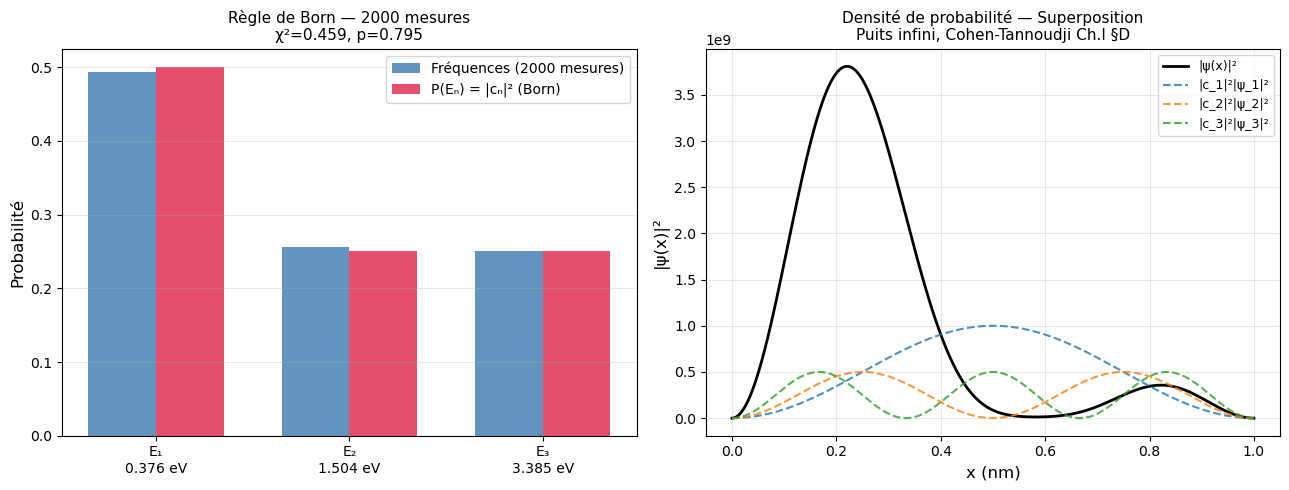

In [5]:
expected_counts = np.array(proba_th) * N_mesures

# Test χ²
chi2_stat, p_value = chisquare(f_obs=counts, f_exp=expected_counts)

print("Test χ² de Pearson — Conformité à la règle de Born")
print(f"  χ² = {chi2_stat:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  ✓ Distribution conforme (p > 0.05) : {p_value > 0.05}")
print(f"\n  Interprétation : p-value = {p_value:.3f} > 0.05 → on ne peut pas")
print(f"  rejeter l'hypothèse que les fréquences suivent P(Eₙ) = |cₙ|²")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme comparatif
n_labels = ['E₁', 'E₂', 'E₃']
bar_x = np.arange(3)
width = 0.35

axes[0].bar(bar_x - width/2, freqs,    width, color='steelblue', alpha=0.85, label=f'Fréquences ({N_mesures} mesures)')
axes[0].bar(bar_x + width/2, proba_th, width, color='crimson',   alpha=0.75, label='P(Eₙ) = |cₙ|² (Born)')
axes[0].set_xticks(bar_x)
axes[0].set_xticklabels([f'{nl}\n{E/1.602e-19:.3f} eV' for nl, E in zip(n_labels, energie_vals)])
axes[0].set_ylabel('Probabilité', fontsize=12)
axes[0].set_title(f'Règle de Born — {N_mesures} mesures\nχ²={chi2_stat:.3f}, p={p_value:.3f}', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Densité de probabilité superposition
rho = np.abs(psi_super.wavefunction)**2
axes[1].plot(x*1e9, rho, 'k-', lw=2, label='|ψ(x)|²')
# Contributions individuelles
for n, (psi_n, c_n, col) in enumerate(zip([psi1,psi2,psi3],[c1,c2,c3],['#1f77b4','#ff7f0e','#2ca02c']), start=1):
    axes[1].plot(x*1e9, abs(c_n)**2 * np.abs(psi_n.wavefunction)**2,
                 '--', color=col, lw=1.5, alpha=0.8, label=f'|c_{n}|²|ψ_{n}|²')
axes[1].set_xlabel('x (nm)', fontsize=12)
axes[1].set_ylabel('|ψ(x)|²', fontsize=12)
axes[1].set_title('Densité de probabilité — Superposition\nPuits infini, Cohen-Tannoudji Ch.I §D', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/02_born_rule.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Réduction du paquet d'ondes (Postulat IV — Règle R2.3)

**Expérience :** Mesurer l'énergie sur $|\psi\rangle$, obtenir $E_n$, puis remesurer immédiatement.

La deuxième mesure donne **toujours** $E_n$ avec probabilité 1.

$$|\psi\rangle \xrightarrow{\text{mesure} = E_n} |\psi'\rangle = |\psi_n\rangle \xrightarrow{\text{re-mesure}} E_n \text{ avec proba } 1$$

In [6]:
N_trials = 500
np.random.seed(0)

def projeter(psi_state, psi_n_state, dx):
    """Réduction R2.3 : |ψ'⟩ = Pₙ|ψ⟩ / √⟨ψ|Pₙ|ψ⟩"""
    overlap = inner_product(psi_n_state.wavefunction, psi_state.wavefunction, dx)
    prob    = abs(overlap)**2
    if prob < 1e-15:
        raise ValueError("Projection nulle — état orthogonal")
    psi_proj = overlap * psi_n_state.wavefunction
    psi_proj /= np.sqrt(prob)
    return WaveFunctionState(x, psi_proj)

eigenstates = [psi1, psi2, psi3]
proba_retest = {1: [], 2: [], 3: []}

for trial in range(N_trials):
    # Première mesure → tirage Born
    n_mes = np.random.choice([0,1,2], p=proba_th)  # index 0,1,2
    
    # Réduction état
    psi_after = projeter(psi_super, eigenstates[n_mes], dx)
    
    # Deuxième mesure → doit donner le même état
    overlaps_after = [
        abs(inner_product(eigenstates[k].wavefunction, psi_after.wavefunction, dx))**2
        for k in range(3)
    ]
    prob_same = overlaps_after[n_mes]
    proba_retest[n_mes + 1].append(prob_same)

print("Réduction du paquet d'ondes — Vérification R2.3")
print("-" * 55)
for n in [1, 2, 3]:
    vals = proba_retest[n]
    if vals:
        print(f"  Après mesure Eₙ n={n} : P(re-mesure = Eₙ) = "
              f"{np.mean(vals):.8f} ± {np.std(vals):.2e}  (doit être 1)")
    else:
        print(f"  n={n} : aucune mesure obtenue sur {N_trials} essais")

print(f"\n  ✓ Réduction vérifiée : la deuxième mesure donne toujours le même résultat.")

Réduction du paquet d'ondes — Vérification R2.3
-------------------------------------------------------
  Après mesure Eₙ n=1 : P(re-mesure = Eₙ) = 1.00000000 ± 0.00e+00  (doit être 1)
  Après mesure Eₙ n=2 : P(re-mesure = Eₙ) = 1.00000000 ± 1.11e-16  (doit être 1)
  Après mesure Eₙ n=3 : P(re-mesure = Eₙ) = 1.00000000 ± 1.11e-16  (doit être 1)

  ✓ Réduction vérifiée : la deuxième mesure donne toujours le même résultat.


## 6. Visualisation — Avant et après réduction

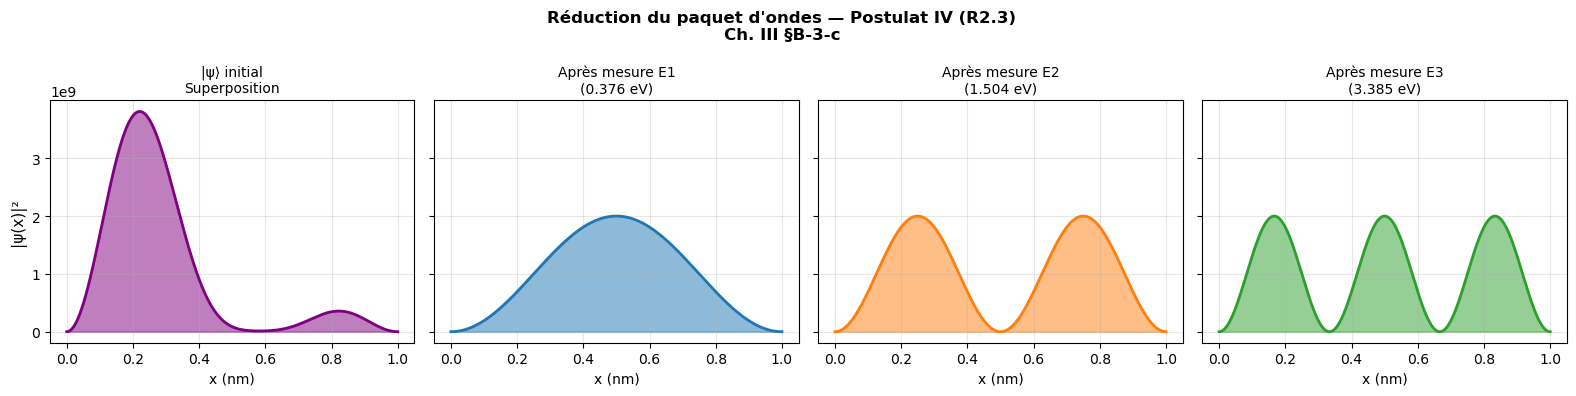

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

rho_super = np.abs(psi_super.wavefunction)**2

# État initial
axes[0].fill_between(x*1e9, rho_super, alpha=0.5, color='purple')
axes[0].plot(x*1e9, rho_super, 'purple', lw=2)
axes[0].set_title('|ψ⟩ initial\nSuperposition', fontsize=10)

# Après mesure de E₁, E₂, E₃
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for k, (psi_n, col, E) in enumerate(zip(eigenstates, colors, energie_vals)):
    psi_after = projeter(psi_super, psi_n, dx)
    rho_after = np.abs(psi_after.wavefunction)**2
    axes[k+1].fill_between(x*1e9, rho_after, alpha=0.5, color=col)
    axes[k+1].plot(x*1e9, rho_after, color=col, lw=2)
    axes[k+1].set_title(f'Après mesure E{k+1}\n({E/1.602e-19:.3f} eV)', fontsize=10)

for ax in axes:
    ax.set_xlabel('x (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('|ψ(x)|²', fontsize=11)

fig.suptitle('Réduction du paquet d\'ondes — Postulat IV (R2.3)\nCh. III §B-3-c', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../results/02_wavefunction_collapse.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

| Résultat | Règle | Statut |
|---|---|---|
| Probabilités numériques = |cₙ|² | R2.2 (Born) | ✓ |
| Distribution empirique conforme (test χ²) | R2.2 (statistique) | ✓ |
| Deuxième mesure = première mesure | R2.3 (réduction) | ✓ |

**Interprétation :** La superposition quantique n'est pas un manque d'information sur un état déterministe caché — c'est une propriété intrinsèque. La mesure projette l'état sur un état propre, et toute mesure ultérieure retrouve ce même état : c'est le **collapse** du paquet d'ondes.